In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/economic_master_dataset.csv")


In [2]:
print(df.head())

                  Country Name Country Code  Year           GDP  GDP_Growth  \
0  Africa Eastern and Southern          AFE  1991  2.769185e+11   -0.106034   
1                    Australia          AUS  1991  3.264164e+11   -0.384631   
2                      Austria          AUT  1991  1.731134e+11    3.441627   
3                      Belgium          BEL  1991  2.105110e+11    1.833074   
4                 Burkina Faso          BFA  1991  3.135046e+09    9.069984   

   Inflation  Unemployment   Population    Exports  
0  17.678100      8.050809  320442961.0  18.440862  
1   3.176675      9.586000   17284036.0  16.006723  
2   3.337427      3.420000    7754891.0  34.726507  
3   3.215311      6.984000   10004486.0  60.229655  
4   2.162601      2.467000    9394632.0  10.447548  


In [4]:
from sklearn.preprocessing import minmax_scale
# Normalize the indicators
features = ["GDP_Growth", "Unemployment", "Inflation", "Exports"]
df_scaled = df.copy()
df_scaled[features] = minmax_scale(df[features])

In [6]:
print(df_scaled.head())

                  Country Name Country Code  Year           GDP  GDP_Growth  \
0  Africa Eastern and Southern          AFE  1991  2.769185e+11    0.423805   
1                    Australia          AUS  1991  3.264164e+11    0.421958   
2                      Austria          AUT  1991  1.731134e+11    0.447319   
3                      Belgium          BEL  1991  2.105110e+11    0.436657   
4                 Burkina Faso          BFA  1991  3.135046e+09    0.484624   

   Inflation  Unemployment   Population   Exports  
0   0.001452      0.205447  320442961.0  0.080508  
1   0.000842      0.245116   17284036.0  0.069878  
2   0.000849      0.085788    7754891.0  0.151628  
3   0.000844      0.177881   10004486.0  0.263001  
4   0.000800      0.061163    9394632.0  0.045601  


Add Economic Health Score 

0.4* GDP_growth

0.2* Exports

0.2*(1 - Unemployment)

0.2*(1- Inflation)

In [7]:
df_scaled["Economic_Health_Score"] =  (
    0.4*df_scaled["GDP_Growth"] +
    0.2*df_scaled["Exports"] +
    0.2*(1 - df_scaled["Unemployment"]) +  # Invert unemployment
    0.2*(1 - df_scaled["Inflation"])        # Invert inflation
)

In [10]:
print(df_scaled[["Country Name", "Economic_Health_Score"]].sort_values("Economic_Health_Score", ascending=False).head())

          Country Name  Economic_Health_Score
6093  Macao SAR, China               0.839146
217             Kuwait               0.820533
2765         Singapore               0.770061
3887             Libya               0.760376
3546         Singapore               0.760286


In [11]:
ranking = df_scaled.groupby("Country Name")["Economic_Health_Score"].mean()
ranking.sort_values(ascending=False).head(10)


Country Name
Singapore               0.727111
Hong Kong SAR, China    0.702222
Luxembourg              0.694318
United Arab Emirates    0.645089
Bahrain                 0.644620
Malaysia                0.643777
Macao SAR, China        0.641348
Qatar                   0.640396
Malta                   0.637188
Viet Nam                0.636412
Name: Economic_Health_Score, dtype: float64

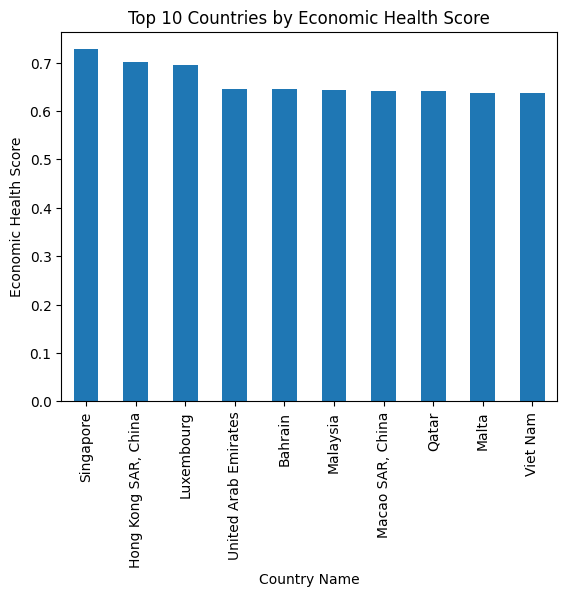

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
top_countries = ranking.sort_values(ascending=False).head(10)
top_countries.plot(kind="bar", title="Top 10 Countries by Economic Health Score")
plt.ylabel("Economic Health Score")
plt.show()


In [15]:
df_scaled.to_csv("../data/processed/economic_health_scores.csv", index=False)